In [1]:
import os
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "data" / "origin_data.xlsx"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"
TAB_DIR = RESULTS_DIR / "tables"



=== Train Metrics ===
MAE : 1.4252
MSE : 7.4667
RMSE: 2.7325
MAPE: 0.0378
R2  : 0.9924

=== Test Metrics ===
MAE : 4.1624
MSE : 43.9931
RMSE: 6.6327
MAPE: 0.1299
R2  : 0.9507


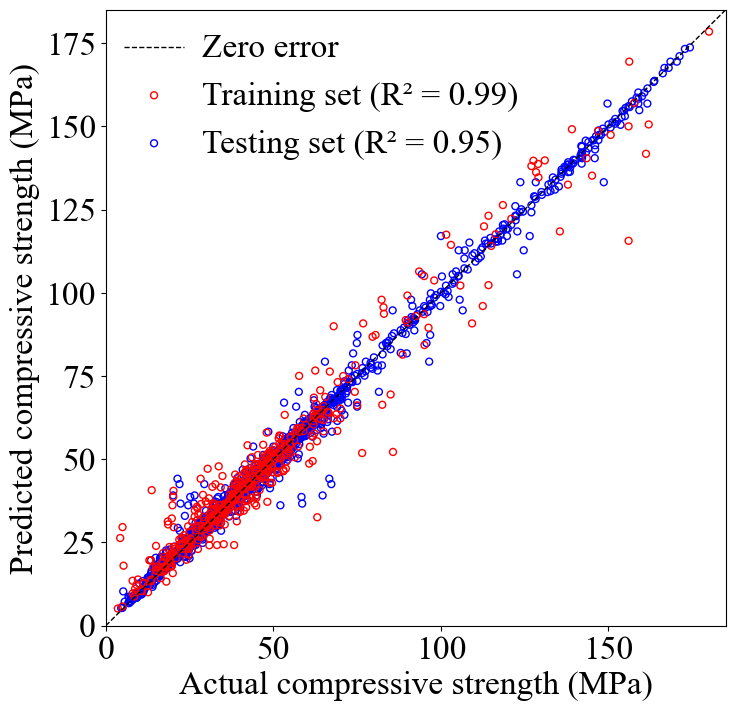

In [2]:
import sys
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from src.data_process import DataHandler
from src.model_train import train_xgboost
from src.plotter import DataPlotter

data_handler = DataHandler(str(DATA_PATH), n_features=16)
data_handler.load_data()

X, y = data_handler.a, data_handler.b
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=172)

result = train_xgboost(x_train, y_train, x_test, y_test)

# plot baseline
y_train_true = result.y_train_true if result.y_train_true is not None else y_train
y_test_true  = result.y_test_true  if result.y_test_true  is not None else y_test

plotter = DataPlotter()
fig, ax = plotter.plot(
    y_train_true, result.y_train_pred,
    y_test_true, result.y_test_pred,
    result.metrics["train"]["r2"], result.metrics["test"]["r2"],
)
fig.savefig(FIG_DIR / "baseline_pred.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


,ratio,n_synthetic,total_samples,test_rmse,test_r2
0,0.0,0,2307,5.571206,0.966847
1,0.2,461,2768,6.794612,0.938157
2,0.4,922,3229,7.153970,0.928115
3,0.6,1384,3691,7.555299,0.918239
4,0.8,1845,4152,7.550935,0.908429
5,1.0,2307,4614,7.029213,0.931252


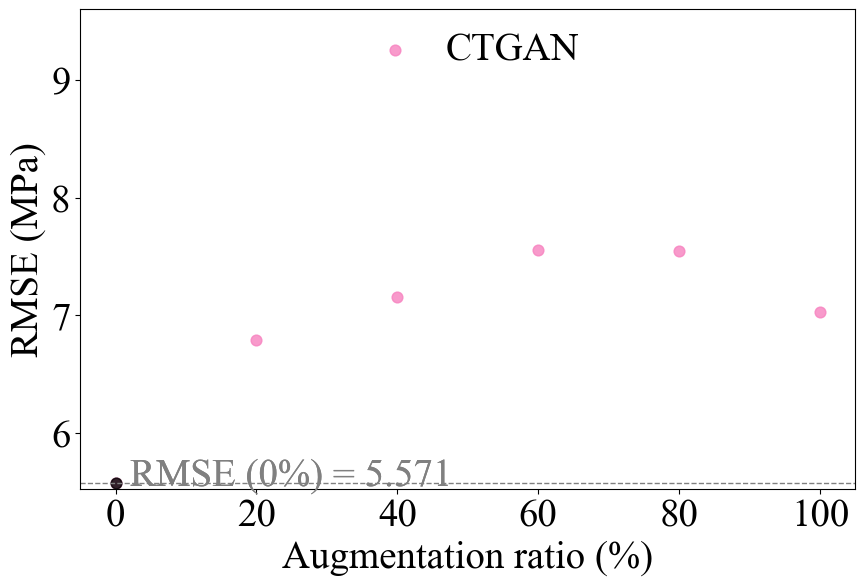

In [3]:
import pandas as pd

aug_csv = TAB_DIR / "augmentation_experiment.csv"
if not aug_csv.exists():
    raise FileNotFoundError(
        f"找不到 {aug_csv}。\n"
        "请先运行 notebooks/02_research_full.ipynb 生成增强实验结果。"
    )

aug_results = pd.read_csv(aug_csv)
display(aug_results)

fig, ax = plotter.plot_aug_results_rmse(
    aug_results,
    ylabel="RMSE (MPa)",
    save_path=str(FIG_DIR / "augmentation_rmse.png")
)
plt.show()
plt.close(fig)


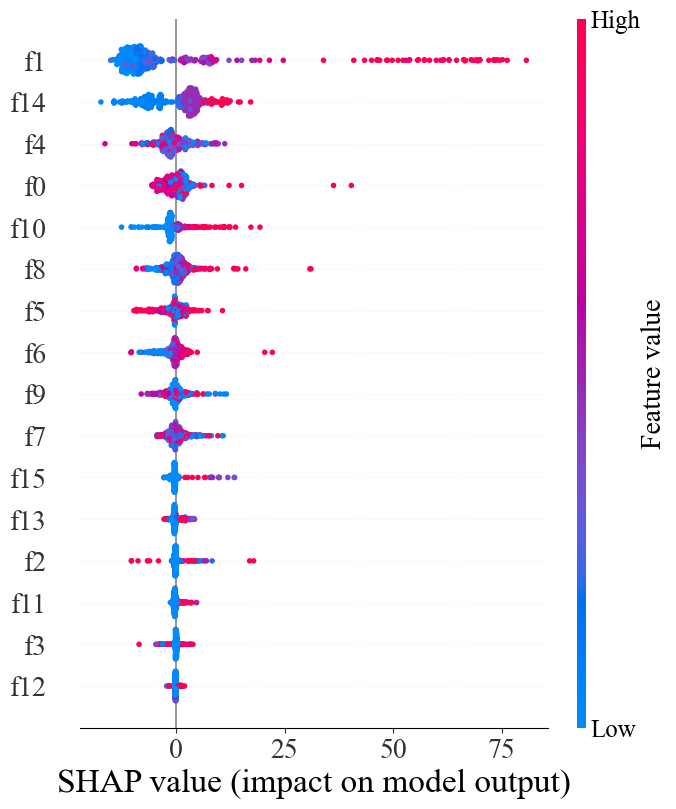

In [4]:
from src.shap import compute_shap_values
from src.plotter import DataPlotter

# x_test -> DataFrame（让特征名自动显示）
if isinstance(x_test, pd.DataFrame):
    x_test_df = x_test
else:
    x_test_df = pd.DataFrame(x_test, columns=[f"f{i}" for i in range(x_test.shape[1])])

shap_values = compute_shap_values(result.model, x_test_df, check_additivity=False)

plotter = DataPlotter()
fig, ax = plotter.plot_shap_summary(shap_values, x_test_df)

plt.show()
plt.close(fig)


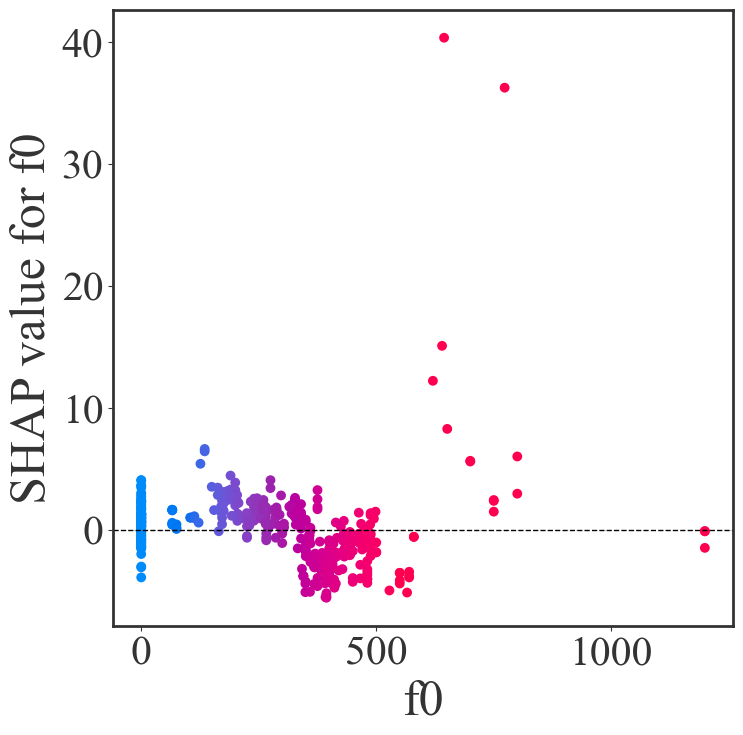

In [5]:
from src.plotter import DataPlotter

plotter = DataPlotter()

save_dir = r"..\results\figures\shap_scatter"
os.makedirs(save_dir, exist_ok=True)

# 画第 0 个特征（展示用足够）
fig, ax = plotter.plot_shap_scatter_one(
    shap_values=shap_values,
    x_data=x_test_df,
    feature=0,
    save_path=os.path.join(save_dir, "shap_scatter_demo_f0.png"),
    point_size=50
)

plt.show()
plt.close(fig)
